# 03 - Training

Fine-tune a pretrained ResNet18 on the processed images from `02_preprocessing`,
once on the `full` version and once on the `cropped` version, and compare them on the validation set.

## 1. Imports

In [5]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets, models, transforms
from sklearn.utils.class_weight import compute_class_weight
from tqdm.auto import tqdm

## 2. Device

In [6]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

## 3. Paths and settings

`MAX_EPOCHS` is an upper limit: training stops earlier when the validation loss has not improved for `PATIENCE` epochs (early stopping).
The best model is saved in `outputs/models/`.

In [20]:
PROCESSED_DIR = Path("..") / "data" / "processed"
FULL_DIR = PROCESSED_DIR / "full"
CROPPED_DIR = PROCESSED_DIR / "cropped"
MODEL_DIR = Path("..") / "outputs" / "models"
MODEL_DIR.mkdir(parents=True, exist_ok=True)

BATCH_SIZE = 32
MAX_EPOCHS = 30
PATIENCE = 5

torch.manual_seed(42)

## 4. Augmentation

### 4.1 What each step does

Augmentation = small random changes to the training images. Every epoch the model sees a slightly different version of each image,
so it learns what a brain and a tumor look like instead of memorizing exact pixels.

- **Flip:** mirror left-right. A brain is roughly symmetric, so a mirrored scan is still a realistic scan.
- **Rotate:** turn a few degrees. Patients do not lie exactly straight in the scanner.
- **Blur:** slightly blur the image. Some notumor images are blurrier (upscaled, see `02_preprocessing` 7.4);
  blurring all classes now and then makes sharpness useless as a shortcut.

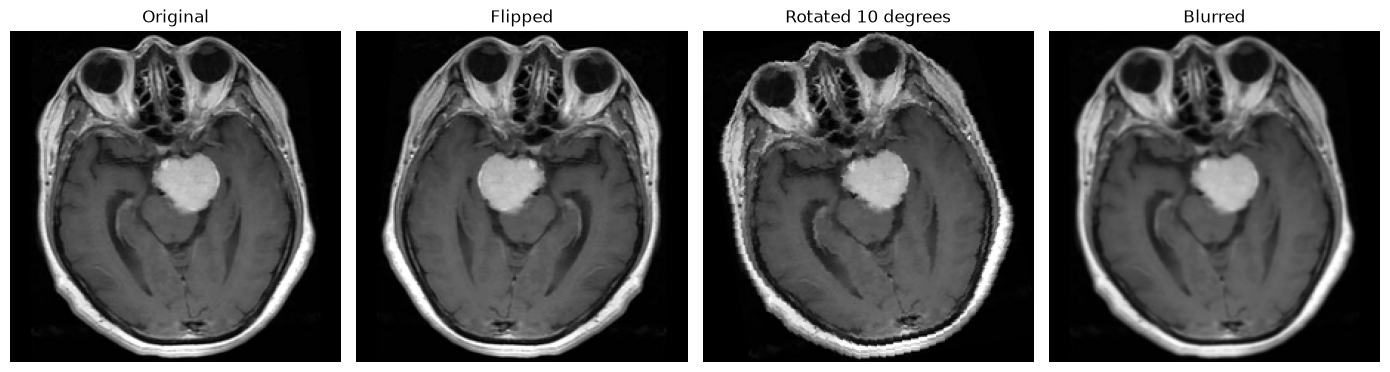

In [8]:
example = Image.open(next((CROPPED_DIR / "train" / "meningioma").glob("*.png")))

flipped = transforms.functional.hflip(example)
rotated = transforms.functional.rotate(example, 10)
blurred = transforms.functional.gaussian_blur(example, kernel_size=3)

fig, axes = plt.subplots(1, 4, figsize=(14, 4))
for ax, img, title in zip(axes, [example, flipped, rotated, blurred], ["Original", "Flipped", "Rotated 10 degrees", "Blurred"]):
    ax.imshow(img, cmap="gray", vmin=0, vmax=255)
    ax.set_title(title)
    ax.axis("off")
plt.tight_layout()
plt.show()

### 4.2 Transforms

Training images get the three augmentation steps from 4.1. Validation images do not, so they are measured the same way every time.
Both are turned into 3 channels (ResNet18 expects color images) and scaled the way ResNet18 was trained.

In [9]:
weights = models.ResNet18_Weights.DEFAULT
MEAN = weights.transforms().mean
STD = weights.transforms().std

train_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.RandomApply([transforms.GaussianBlur(kernel_size=3)], p=0.3),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

eval_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

## 5. Datasets and loaders

`ImageFolder` takes the label from the folder name. The `DataLoader` gives the images in batches of 32;
the training batches are shuffled every epoch, the validation batches are not.
Everything is created twice: once for `full`, once for `cropped`.

In [10]:
full_train_data = datasets.ImageFolder(FULL_DIR / "train", transform=train_transform)
full_val_data = datasets.ImageFolder(FULL_DIR / "val", transform=eval_transform)
cropped_train_data = datasets.ImageFolder(CROPPED_DIR / "train", transform=train_transform)
cropped_val_data = datasets.ImageFolder(CROPPED_DIR / "val", transform=eval_transform)

full_train_loader = DataLoader(full_train_data, batch_size=BATCH_SIZE, shuffle=True)
full_val_loader = DataLoader(full_val_data, batch_size=BATCH_SIZE, shuffle=False)
cropped_train_loader = DataLoader(cropped_train_data, batch_size=BATCH_SIZE, shuffle=True)
cropped_val_loader = DataLoader(cropped_val_data, batch_size=BATCH_SIZE, shuffle=False)

pd.DataFrame({
    "full": [len(full_train_data), len(full_val_data)],
    "cropped": [len(cropped_train_data), len(cropped_val_data)],
}, index=["train", "val"])

,full,cropped
train,4023,4023
val,710,710


## 6. One training batch

What's going into the model?

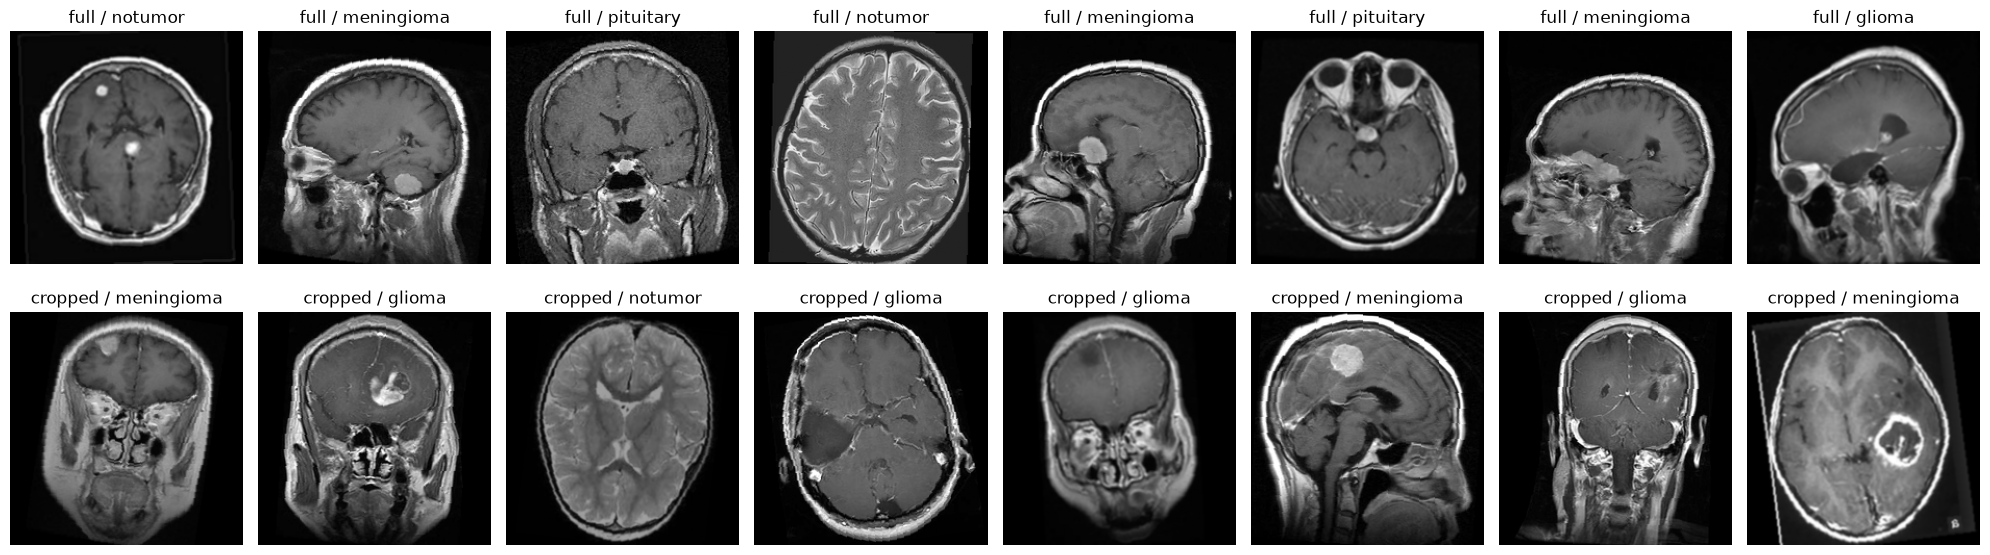

In [11]:
full_images, full_labels = next(iter(full_train_loader))
cropped_images, cropped_labels = next(iter(cropped_train_loader))

fig, axes = plt.subplots(2, 8, figsize=(20, 6))
for i in range(8):
    axes[0, i].imshow(full_images[i, 0] * STD[0] + MEAN[0], cmap="gray", vmin=0, vmax=1)
    axes[0, i].set_title(f"full / {full_train_data.classes[full_labels[i]]}")
    axes[1, i].imshow(cropped_images[i, 0] * STD[0] + MEAN[0], cmap="gray", vmin=0, vmax=1)
    axes[1, i].set_title(f"cropped / {cropped_train_data.classes[cropped_labels[i]]}")
for ax in axes.flat:
    ax.axis("off")
plt.tight_layout()
plt.show()

### Conclusions

- Both versions have 4,023 training and 710 validation images, in 4 classes (alphabetical: glioma, meningioma, notumor, pituitary).
- Each batch is 32 images of 3 x 224 x 224.
- The augmented images still look like normal brain scans: the augmentation is mild enough.

## 7. Model

Pretrained ResNet18. Its last layer predicts the 1,000 ImageNet classes, so it is replaced by a new layer with 4 outputs.
Two separate models, one per version. The same seed gives them the same starting weights.

In [12]:
torch.manual_seed(42)
full_model = models.resnet18(weights=weights)
full_model.fc = nn.Linear(full_model.fc.in_features, 4)
full_model = full_model.to(device)

torch.manual_seed(42)
cropped_model = models.resnet18(weights=weights)
cropped_model.fc = nn.Linear(cropped_model.fc.in_features, 4)
cropped_model = cropped_model.to(device)

full_model.fc

Linear(in_features=512, out_features=4, bias=True)

## 8. Class weights and loss

Notumor has about half as many training images. With class weights, a mistake on a rare class counts heavier,
so the model cannot score well by ignoring notumor. Both versions have the same training labels, so they share the weights.

In [13]:
class_weights = compute_class_weight("balanced", classes=np.arange(4), y=full_train_data.targets)
loss_fn = nn.CrossEntropyLoss(weight=torch.tensor(class_weights, dtype=torch.float32).to(device))

pd.Series(class_weights, index=full_train_data.classes).round(2)

glioma        0.85
meningioma    0.93
notumor       1.65
pituitary     0.88
dtype: float64

## 9. Learning rate comparison

Three short runs of 3 epochs on `full`, each with a different learning rate.
Every run starts from the same pretrained model. The learning rate with the lowest validation loss is used for both versions.

One training epoch: for every batch, predict (`model(images)`), compute the loss, compute the gradients (`loss.backward()`)
and take one step (`optimizer.step()`). Then the model is measured on the validation set, without learning (`torch.no_grad()`).

In [15]:
LEARNING_RATES = [0.001, 0.0001, 0.00001]
LR_EPOCHS = 3
lr_val_loss = np.zeros((len(LEARNING_RATES), LR_EPOCHS))

for r, lr in enumerate(LEARNING_RATES):
    torch.manual_seed(42)
    model = models.resnet18(weights=weights)
    model.fc = nn.Linear(model.fc.in_features, 4)
    model = model.to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)

    for epoch in range(LR_EPOCHS):
        model.train()
        for images, labels in tqdm(full_train_loader, desc=f"lr={lr}, epoch {epoch + 1}"):
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            loss = loss_fn(model(images), labels)
            loss.backward()
            optimizer.step()

        model.eval()
        val_loss = 0
        with torch.no_grad():
            for images, labels in full_val_loader:
                images, labels = images.to(device), labels.to(device)
                val_loss += loss_fn(model(images), labels).item() * len(labels)
        lr_val_loss[r, epoch] = val_loss / len(full_val_data)

pd.DataFrame(lr_val_loss, index=LEARNING_RATES, columns=["epoch 1", "epoch 2", "epoch 3"]).round(3)

lr=1e-05, epoch 3: 100%|██████████| 126/126 [00:17<00:00,  7.25it/s]


,epoch 1,epoch 2,epoch 3
0.00100,0.234,0.741,0.662
0.00010,0.134,0.083,0.116
0.00001,0.378,0.261,0.200


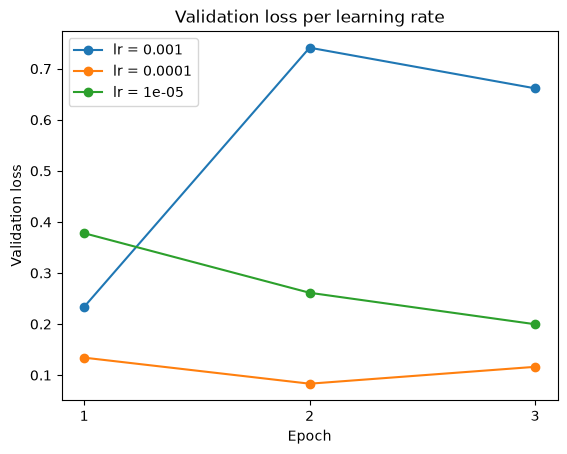

In [16]:
for r, lr in enumerate(LEARNING_RATES):
    plt.plot([1, 2, 3], lr_val_loss[r], marker="o", label=f"lr = {lr}")
plt.title("Validation loss per learning rate")
plt.xlabel("Epoch")
plt.ylabel("Validation loss")
plt.xticks([1, 2, 3])
plt.legend()
plt.show()

In [17]:
LEARNING_RATE = LEARNING_RATES[lr_val_loss[:, -1].argmin()]
LEARNING_RATE

0.0001

## 10. Optimizer and scheduler

AdamW with the learning rate from section 9. The scheduler halves the learning rate when the validation loss has not improved for 2 epochs.
Each model gets its own optimizer and scheduler.

In [18]:
full_optimizer = torch.optim.AdamW(full_model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)
full_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(full_optimizer, mode="min", factor=0.5, patience=2)

cropped_optimizer = torch.optim.AdamW(cropped_model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)
cropped_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(cropped_optimizer, mode="min", factor=0.5, patience=2)

## 11. Train on full

Each epoch: train on all training batches, measure on the validation set, and let the scheduler adjust the learning rate.
When the validation loss is the best so far, the model is saved. After `PATIENCE` epochs without improvement, training stops.

In [21]:
torch.manual_seed(42)
full_history = pd.DataFrame(index=range(1, MAX_EPOCHS + 1), columns=["train_loss", "train_acc", "val_loss", "val_acc", "lr"], dtype=float)
best_val_loss = np.inf
epochs_without_improvement = 0

for epoch in range(1, MAX_EPOCHS + 1):
    full_model.train()
    train_loss, train_correct = 0, 0
    for images, labels in tqdm(full_train_loader, desc=f"Epoch {epoch}"):
        images, labels = images.to(device), labels.to(device)
        full_optimizer.zero_grad()
        outputs = full_model(images)
        loss = loss_fn(outputs, labels)
        loss.backward()
        full_optimizer.step()
        train_loss += loss.item() * len(labels)
        train_correct += (outputs.argmax(dim=1) == labels).sum().item()

    full_model.eval()
    val_loss, val_correct = 0, 0
    with torch.no_grad():
        for images, labels in full_val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = full_model(images)
            val_loss += loss_fn(outputs, labels).item() * len(labels)
            val_correct += (outputs.argmax(dim=1) == labels).sum().item()

    full_history.loc[epoch] = [
        train_loss / len(full_train_data),
        train_correct / len(full_train_data),
        val_loss / len(full_val_data),
        val_correct / len(full_val_data),
        full_optimizer.param_groups[0]["lr"],
    ]
    full_scheduler.step(full_history.loc[epoch, "val_loss"])

    if full_history.loc[epoch, "val_loss"] < best_val_loss:
        best_val_loss = full_history.loc[epoch, "val_loss"]
        epochs_without_improvement = 0
        torch.save(full_model.state_dict(), MODEL_DIR / "resnet18_full.pt")
    else:
        epochs_without_improvement += 1
        if epochs_without_improvement >= PATIENCE:
            break

full_history = full_history.dropna()
full_history.round(5)

Epoch 9: 100%|██████████| 126/126 [00:21<00:00,  5.98it/s]


,train_loss,train_acc,val_loss,val_acc,lr
1,0.2858,0.8909,0.1680,0.9380,0.0001
2,0.1068,0.9615,0.1105,0.9620,0.0001
3,0.0645,0.9789,0.1056,0.9690,0.0001
4,0.0416,0.9876,0.0577,0.9859,0.0001
5,0.0332,0.9893,0.1160,0.9606,0.0001
6,0.0315,0.9886,0.1999,0.9521,0.0001
7,0.0411,0.9851,0.0949,0.9746,0.0001
8,0.0173,0.9948,0.0731,0.9789,0.0000
9,0.0113,0.9973,0.0593,0.9803,0.0000


## 12. Train on cropped

Exactly the same as section 11, but with the cropped images, model, optimizer and scheduler.

In [22]:
torch.manual_seed(42)
cropped_history = pd.DataFrame(index=range(1, MAX_EPOCHS + 1), columns=["train_loss", "train_acc", "val_loss", "val_acc", "lr"], dtype=float)
best_val_loss = np.inf
epochs_without_improvement = 0

for epoch in range(1, MAX_EPOCHS + 1):
    cropped_model.train()
    train_loss, train_correct = 0, 0
    for images, labels in tqdm(cropped_train_loader, desc=f"Epoch {epoch}"):
        images, labels = images.to(device), labels.to(device)
        cropped_optimizer.zero_grad()
        outputs = cropped_model(images)
        loss = loss_fn(outputs, labels)
        loss.backward()
        cropped_optimizer.step()
        train_loss += loss.item() * len(labels)
        train_correct += (outputs.argmax(dim=1) == labels).sum().item()

    cropped_model.eval()
    val_loss, val_correct = 0, 0
    with torch.no_grad():
        for images, labels in cropped_val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = cropped_model(images)
            val_loss += loss_fn(outputs, labels).item() * len(labels)
            val_correct += (outputs.argmax(dim=1) == labels).sum().item()

    cropped_history.loc[epoch] = [
        train_loss / len(cropped_train_data),
        train_correct / len(cropped_train_data),
        val_loss / len(cropped_val_data),
        val_correct / len(cropped_val_data),
        cropped_optimizer.param_groups[0]["lr"],
    ]
    cropped_scheduler.step(cropped_history.loc[epoch, "val_loss"])

    if cropped_history.loc[epoch, "val_loss"] < best_val_loss:
        best_val_loss = cropped_history.loc[epoch, "val_loss"]
        epochs_without_improvement = 0
        torch.save(cropped_model.state_dict(), MODEL_DIR / "resnet18_cropped.pt")
    else:
        epochs_without_improvement += 1
        if epochs_without_improvement >= PATIENCE:
            break

cropped_history = cropped_history.dropna()
cropped_history.round(5)

Epoch 17: 100%|██████████| 126/126 [00:20<00:00,  6.05it/s]


,train_loss,train_acc,val_loss,val_acc,lr
1,0.2990,0.8842,0.1950,0.9268,0.0001
2,0.1083,0.9605,0.1212,0.9648,0.0001
3,0.0639,0.9769,0.0663,0.9817,0.0001
4,0.0361,0.9888,0.0765,0.9775,0.0001
5,0.0362,0.9866,0.0615,0.9732,0.0001
6,0.0326,0.9878,0.0747,0.9789,0.0001
7,0.0339,0.9876,0.1271,0.9634,0.0001
8,0.0168,0.9943,0.0522,0.9831,0.0001
9,0.0148,0.9953,0.0540,0.9873,0.0001
10,0.0111,0.9968,0.0529,0.9845,0.0001


## 13. Training curves

Loss and accuracy per epoch. When the training loss keeps falling but the validation loss goes up, the model is overfitting.

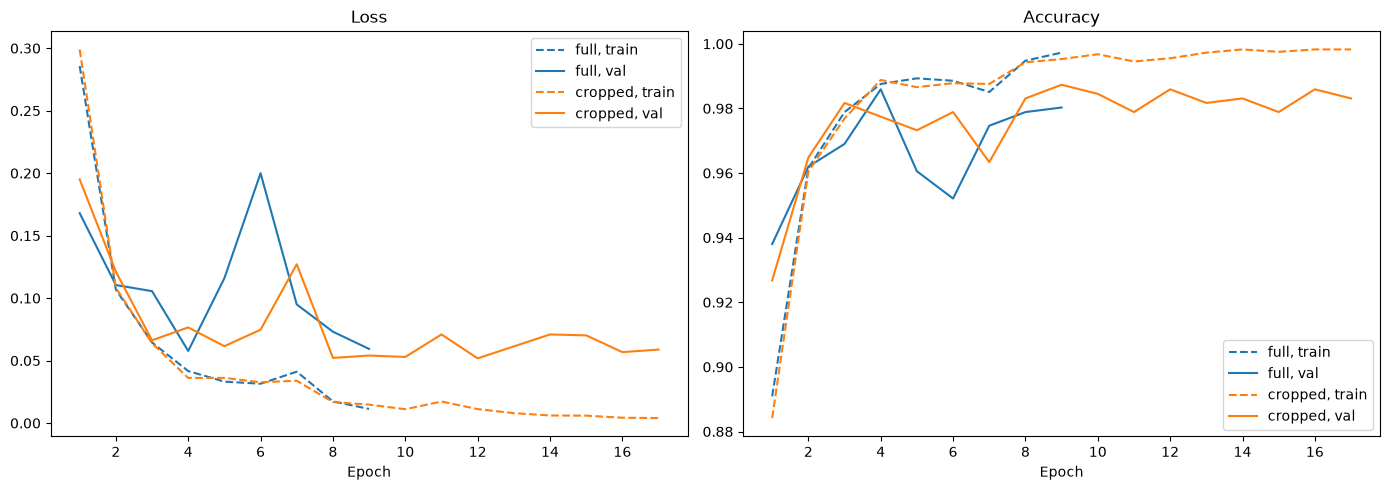

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(full_history["train_loss"], color="tab:blue", linestyle="--", label="full, train")
axes[0].plot(full_history["val_loss"], color="tab:blue", label="full, val")
axes[0].plot(cropped_history["train_loss"], color="tab:orange", linestyle="--", label="cropped, train")
axes[0].plot(cropped_history["val_loss"], color="tab:orange", label="cropped, val")
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(full_history["train_acc"], color="tab:blue", linestyle="--", label="full, train")
axes[1].plot(full_history["val_acc"], color="tab:blue", label="full, val")
axes[1].plot(cropped_history["train_acc"], color="tab:orange", linestyle="--", label="cropped, train")
axes[1].plot(cropped_history["val_acc"], color="tab:orange", label="cropped, val")
axes[1].set_title("Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].legend()

plt.tight_layout()
plt.show()

## 14. Full vs cropped

The epoch with the lowest validation loss for each version: that is the saved model.

In [24]:
pd.DataFrame({
    "best epoch": [full_history["val_loss"].idxmin(), cropped_history["val_loss"].idxmin()],
    "val loss": [full_history["val_loss"].min(), cropped_history["val_loss"].min()],
    "val accuracy": [full_history.loc[full_history["val_loss"].idxmin(), "val_acc"], cropped_history.loc[cropped_history["val_loss"].idxmin(), "val_acc"]],
}, index=["full", "cropped"]).round(4)

,best epoch,val loss,val accuracy
full,4,0.0577,0.9859
cropped,12,0.0518,0.9859


### Conclusions

- Both models get 98.6% on the validation set (700 out of 710 right). So cropping doesn't really change the score.
- Cropped has a slightly lower validation loss (0.052 vs 0.058), but the loss jumps around way more than that between epochs.
  I only did one run per version, so I don't see this as a real difference.
- Both models overfit a bit (train accuracy goes to ~99.8%), but early stopping keeps the best epoch, so that's fine.
- I'm going with the **cropped** model for the rest of the project. The scores are the same, and without the black border
  the model can't use the border as a shortcut. I picked this before looking at the test set, so the test score stays honest.
- Next: test both models on the test set and use Grad-CAM to see if they look at the same things.

## 15. Version 2

`04_evaluation` showed that the v1 model misses tumors from the second source, because it never saw them during training.
`02_preprocessing` (section 8) made a new split with both sources in every split.
This model is trained exactly like the cropped v1 model (same learning rate, augmentation and early stopping). Only the data changes.

### 15.1 Data and class weights

The class weights are computed again, because the v2 training set has different counts.

In [25]:
V2_DIR = Path("..") / "data" / "processed_v2" / "cropped"

v2_train_data = datasets.ImageFolder(V2_DIR / "train", transform=train_transform)
v2_val_data = datasets.ImageFolder(V2_DIR / "val", transform=eval_transform)

v2_train_loader = DataLoader(v2_train_data, batch_size=BATCH_SIZE, shuffle=True)
v2_val_loader = DataLoader(v2_val_data, batch_size=BATCH_SIZE, shuffle=False)

v2_class_weights = compute_class_weight("balanced", classes=np.arange(4), y=v2_train_data.targets)
v2_loss_fn = nn.CrossEntropyLoss(weight=torch.tensor(v2_class_weights, dtype=torch.float32).to(device))

pd.DataFrame({
    "train images": np.bincount(v2_train_data.targets),
    "class weight": v2_class_weights.round(2),
}, index=v2_train_data.classes)

,train images,class weight
glioma,1241,0.87
meningioma,1166,0.93
notumor,708,1.53
pituitary,1224,0.89


### 15.2 Model, optimizer and training

Same as sections 7, 10 and 12. The best model is saved as `resnet18_v2.pt`.

In [26]:
torch.manual_seed(42)
v2_model = models.resnet18(weights=weights)
v2_model.fc = nn.Linear(v2_model.fc.in_features, 4)
v2_model = v2_model.to(device)

v2_optimizer = torch.optim.AdamW(v2_model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)
v2_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(v2_optimizer, mode="min", factor=0.5, patience=2)

torch.manual_seed(42)
v2_history = pd.DataFrame(index=range(1, MAX_EPOCHS + 1), columns=["train_loss", "train_acc", "val_loss", "val_acc", "lr"], dtype=float)
best_val_loss = np.inf
epochs_without_improvement = 0

for epoch in range(1, MAX_EPOCHS + 1):
    v2_model.train()
    train_loss, train_correct = 0, 0
    for images, labels in tqdm(v2_train_loader, desc=f"Epoch {epoch}"):
        images, labels = images.to(device), labels.to(device)
        v2_optimizer.zero_grad()
        outputs = v2_model(images)
        loss = v2_loss_fn(outputs, labels)
        loss.backward()
        v2_optimizer.step()
        train_loss += loss.item() * len(labels)
        train_correct += (outputs.argmax(dim=1) == labels).sum().item()

    v2_model.eval()
    val_loss, val_correct = 0, 0
    with torch.no_grad():
        for images, labels in v2_val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = v2_model(images)
            val_loss += v2_loss_fn(outputs, labels).item() * len(labels)
            val_correct += (outputs.argmax(dim=1) == labels).sum().item()

    v2_history.loc[epoch] = [
        train_loss / len(v2_train_data),
        train_correct / len(v2_train_data),
        val_loss / len(v2_val_data),
        val_correct / len(v2_val_data),
        v2_optimizer.param_groups[0]["lr"],
    ]
    v2_scheduler.step(v2_history.loc[epoch, "val_loss"])

    if v2_history.loc[epoch, "val_loss"] < best_val_loss:
        best_val_loss = v2_history.loc[epoch, "val_loss"]
        epochs_without_improvement = 0
        torch.save(v2_model.state_dict(), MODEL_DIR / "resnet18_v2.pt")
    else:
        epochs_without_improvement += 1
        if epochs_without_improvement >= PATIENCE:
            break

v2_history = v2_history.dropna()
v2_history.round(5)

Epoch 14: 100%|██████████| 136/136 [00:22<00:00,  6.15it/s]


,train_loss,train_acc,val_loss,val_acc,lr
1,0.32503,0.87947,0.15589,0.94844,0.00010
2,0.11451,0.95921,0.16076,0.95166,0.00010
3,0.08212,0.97373,0.08231,0.96992,0.00010
4,0.05905,0.98018,0.06518,0.97744,0.00010
5,0.03601,0.98825,0.07518,0.98281,0.00010
6,0.04230,0.98617,0.08216,0.98067,0.00010
7,0.03202,0.98894,0.09158,0.97315,0.00010
8,0.01696,0.99424,0.06597,0.98174,0.00005
9,0.01200,0.99562,0.05883,0.98389,0.00005
10,0.00970,0.99746,0.06640,0.98174,0.00005


### 15.3 Training curves and best epoch

The v2 validation set is different from v1 (it now also has other-source tumors), so these numbers can't be compared directly with v1.
The fair comparison happens on the test set in `04_evaluation`.

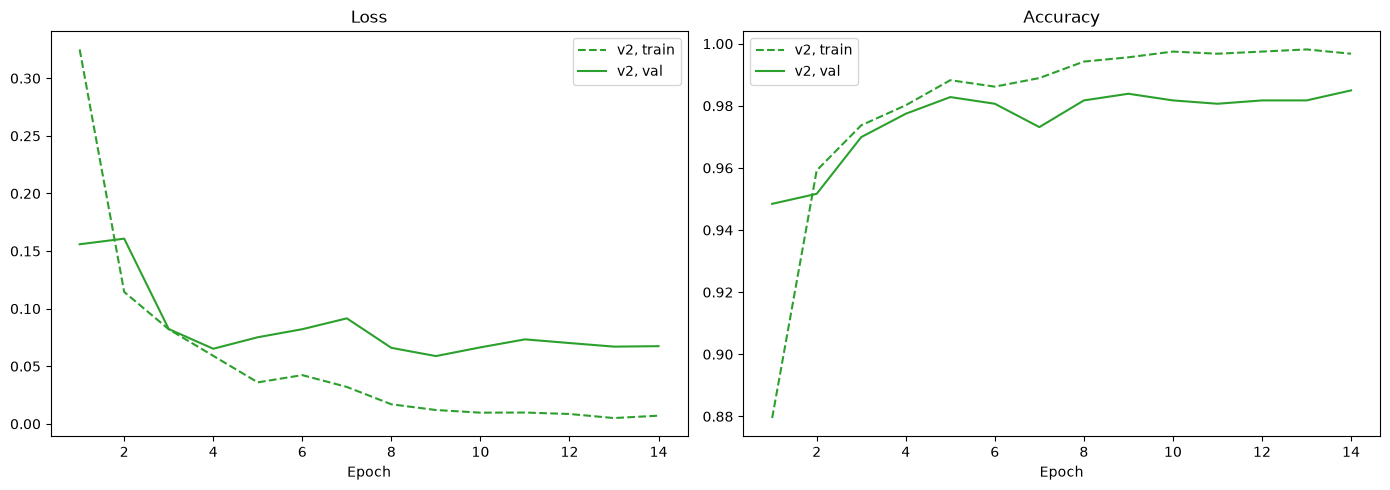

(9, np.float64(0.0588), np.float64(0.9839))

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(v2_history["train_loss"], color="tab:green", linestyle="--", label="v2, train")
axes[0].plot(v2_history["val_loss"], color="tab:green", label="v2, val")
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(v2_history["train_acc"], color="tab:green", linestyle="--", label="v2, train")
axes[1].plot(v2_history["val_acc"], color="tab:green", label="v2, val")
axes[1].set_title("Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].legend()

plt.tight_layout()
plt.show()

best_epoch = v2_history["val_loss"].idxmin()
best_epoch, v2_history.loc[best_epoch, "val_loss"].round(4), v2_history.loc[best_epoch, "val_acc"].round(4)

### 15.4 Conclusions

- The best v2 model is from epoch 9: 98.4% on the v2 validation set (val loss 0.059). Training stopped after epoch 14.
- That is about the same as v1 (98.6%), but the v2 validation set is harder: it also has tumors from the other source,
  which v1 got wrong a lot. So keeping the same score here is already a good sign.
- Same training pattern as v1: fast learning in the first epochs, then the validation loss jumps around and the scheduler lowers the learning rate.
- Whether v2 really fixes the source problem is checked in `04_evaluation`, on test images that neither model has seen.